# Diagnóstico de Missing Values #

**Missing values** são dados ausentes (NaN, None). Eles podem indicar falhas de coleta, erros de entrada ou simplesmente ausência de informação.

**Como identificar:**

1. Contar valores nulos por coluna

df.isnull().sum()

2. Percentual de nulos

df.isnull().mean() * 100


**Interpretação**

• 	Se uma coluna tem poucos nulos (<5%), pode ser seguro preencher ou excluir.

• 	Se tem muitos nulos (>30%), talvez seja melhor descartar a variável ou investigar a causa.

# Estratégias simples para tratar Missing Value #

**1. Remoção de linhas:** se poucos registros têm nulos.

    Código: 
        
        df.dropna(subset=['Income'], inplace=True)


**2. Imputação simples:**
    
    • Numéricos: média, mediana ou moda.
    
        Código: 
            
            df['Income'].fillna(df['Income'].median(), inplace=True)

    • Categóricos: valor mais frequente.
    
        Código:
            
            df['Education'].fillna(df['Education'].mode()[0], inplace=True)
    
    • Criação da categoria "Desconhecido" para variáveis categóricas.
       
       Código:
       
           df['Education'].fillna('Unknown', inplace=True)

# Diagnóstico de Outliers #

**Outliers** são valores muito diferentes do padrão, que podem distorcer médias e análises. 

**Como identificar:**

**1. Boxplot (visualização):**

    Código: 
        import seaborn as sns
        sns.boxplot(x=df['Income'])
        
**2. Regra do IQR (Interquartile Range):**

    Código:
    
        Q1 = df['Income'].quantile(0.25)

        Q3 = df['Income'].quantile(0.75)

        IQR = Q3 - Q1


        limite_inferior = Q1 - 1.5 * IQR

        limite_superior = Q3 + 1.5 * IQR


        outliers = df[(df['Income'] < limite_inferior) | (df['Income'] > limite_superior)]


# Estratégias simples para tratar Outliers #

**1. Remoção:** excluir registros fora dos limites.

    Código: 
    
        df = df[(df['Income'] >= limite_inferior) & (df['Income'] <= limite_superior)]


**2. Winsorização:** limitar valores extremos ao máximo permitido.

    Código: 
        
        df['Income'] = df['Income'].clip(lower=limite_inferior, upper=limite_superior)
        
        
**3. Transformação:** aplicar log ou raiz quadrada para reduzir impacto.

    Código: 
        
        import numpy as np
        df['Income_log'] = np.log1p(df['Income'])



# Entregável obrigatório #

No dataset escolhido, produzir um **diagnóstico de missing** (% por coluna) e **identificar outliers** em pelo menos 2 variáveis numéricas (boxplot ou regra de 1.5 IQR). Propor qual tratamento faria (remoção, imputação, winsorizar).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")

In [3]:
print(len(df))

30000


In [4]:
# Diagnóstico de Missing Values 

missing = df.isnull().mean() * 100
print("Percentual de missing por coluna: \n", missing)

Percentual de missing por coluna: 
 ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default.payment.next.month    0.0
dtype: float64


**Resultado:** todas as colunas com 0.0, ou seja, 0% de missing.

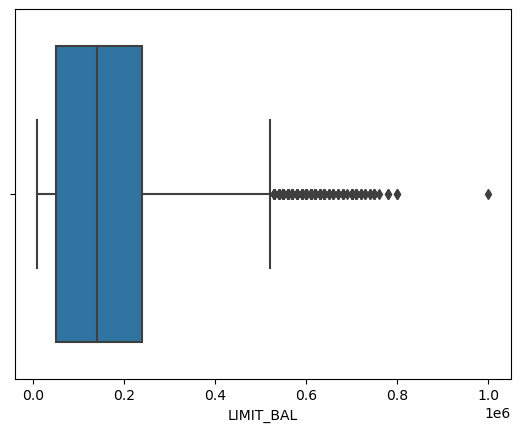

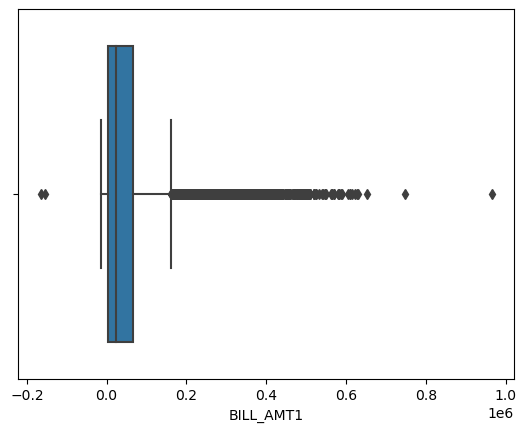

In [5]:
# Identificação de outliers com duas variáveis usando boxplot

# 1) LIMIT_BAL (limite de crédito)

sns.boxplot(x=df['LIMIT_BAL'])
plt.show()

# 2) BILL_AMT1 (valor da faturo no mês 1)

sns.boxplot(x=df['BILL_AMT1'])
plt.show()

In [6]:
# Identificação de outliers com duas variáveis usando regra IQR

# 1) LIMIT_BAL (limite de crédito)

q1 = df['LIMIT_BAL'].quantile(0.25)
q3 = df['LIMIT_BAL'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

out_limit_bal = df[(df['LIMIT_BAL'] < lim_inf) | (df['LIMIT_BAL'] > lim_sup)]
print("Limite inferior LIMIT_BAL:", lim_inf)
print("Limite superior LIMIT_BAL:", lim_sup)
print("Outliers em LIMIT_BAL:", out_limit_bal.shape[0])


# 2) BILL_AMT1 (valor da faturo no mês 1)

q1 = df['BILL_AMT1'].quantile(0.25)
q3 = df['BILL_AMT1'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

out_limit_bal = df[(df['BILL_AMT1'] < lim_inf) | (df['BILL_AMT1'] > lim_sup)]
print("Limite inferior BILL_AMT1:", lim_inf)
print("Limite superior BILL_AMT1:", lim_sup)
print("Outliers em BILL_AMT1:", out_limit_bal.shape[0])

Limite inferior LIMIT_BAL: -235000.0
Limite superior LIMIT_BAL: 525000.0
Outliers em LIMIT_BAL: 167
Limite inferior BILL_AMT1: -91739.625
Limite superior BILL_AMT1: 162389.375
Outliers em BILL_AMT1: 2400


**Estratégias de Tratamento**

1) LIMIT_BAL:
    
   - Outliers são clientes com limites muito altos.
   
   - Estratégia: winsorização (limitar valores ao máximo permitido pelo IQR) ou transformação logarítmica para reduzir a assimetria.
    
   - Não remover, pois são clientes válidos.

2) BILL_AMT1:
   
   - Outliers são faturas muito altas ou negativas (créditos).
    
   - Estratégia: winsorização para limitar valores extremos e manter representatividade.
   
   - Valores negativos podem ser mantidos, pois representam crédito ou estorno.


# Entregável avançado #

Em Python: implementar o tratamento proposto (ex.: imputar mediana, criar flag de missing, winsorizar outliers) e comparar estatísticas antes/depois.

In [7]:
# Diagnóstico de Missing Values 

print("Percentual de missing por coluna: \n", missing)

Percentual de missing por coluna: 
 ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default.payment.next.month    0.0
dtype: float64


In [8]:
# 2. Identificação de Outliers (IQR)

def detectar_out(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    out_limit_bal = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    return out_limit_bal.shape[0], lim_inf, lim_sup

out_limit, li_limit, ls_limit = detectar_out('LIMIT_BAL')
out_bill, li_bill, ls_bill = detectar_out('BILL_AMT1')

print(f"Outliers em LIMIT_BAL: {out_limit}")
print(f"Outliers em BILL_AMT1: {out_bill}")

Outliers em LIMIT_BAL: 167
Outliers em BILL_AMT1: 2400


In [13]:
# 3. Tratamento de outliers 

# Winsorização

# Winsorizar LIMIT_BAL e BILL_AMT1 (limitar extremos a 5%)
df['LIMIT_BAL_wins'] = winsorize(df['LIMIT_BAL'], limits=[0.05, 0.05])
df['BILL_AMT1_wins'] = winsorize(df['BILL_AMT1'], limits=[0.05, 0.05])

In [29]:
# Criar flag

df['LIMIT_BAL_missing'] = df['LIMIT_BAL'].isnull().astype(int)
df['BILL_AMT1_missing'] = df['LIMIT_BAL'].isnull().astype(int)

print("\nEstatísticas LIMIT_BAL antes:")
print(df['LIMIT_BAL'].describe().round(2))
print("\nEstatísticas LIMIT_BAL depois:")
print(df['LIMIT_BAL_missing'].describe().round(2))
print("\nEstatísticas BILL_AMT1 antes:")
print(df['BILL_AMT1'].describe().round(2))
print("\nEstatísticas BILL_AMT1 depois:")
print(df['BILL_AMT1_missing'].describe().round(2))


Estatísticas LIMIT_BAL antes:
count      30000.00
mean      167484.32
std       129747.66
min        10000.00
25%        50000.00
50%       140000.00
75%       240000.00
max      1000000.00
Name: LIMIT_BAL, dtype: float64

Estatísticas LIMIT_BAL depois:
count    30000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: LIMIT_BAL_missing, dtype: float64

Estatísticas BILL_AMT1 antes:
count     30000.00
mean      51223.33
std       73635.86
min     -165580.00
25%        3558.75
50%       22381.50
75%       67091.00
max      964511.00
Name: BILL_AMT1, dtype: float64

Estatísticas BILL_AMT1 depois:
count    30000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: BILL_AMT1_missing, dtype: float64


In [28]:
# Imputar a mediana

mediana = df['LIMIT_BAL'].median()
df['LIMIT_BAL_mediana'] = df['LIMIT_BAL'].fillna(mediana)

mediana = df['BILL_AMT1'].median()
df['BILL_AMT1_mediana'] = df['BILL_AMT1'].fillna(mediana)

print("\nEstatísticas LIMIT_BAL antes:")
print(df['LIMIT_BAL'].describe().round(2))
print("\nEstatísticas LIMIT_BAL depois:")
print(df['LIMIT_BAL_mediana'].describe().round(2))
print("\nEstatísticas BILL_AMT1 antes:")
print(df['BILL_AMT1'].describe().round(2))
print("\nEstatísticas BILL_AMT1 depois:")
print(df['BILL_AMT1_mediana'].describe().round(2))


Estatísticas LIMIT_BAL antes:
count      30000.00
mean      167484.32
std       129747.66
min        10000.00
25%        50000.00
50%       140000.00
75%       240000.00
max      1000000.00
Name: LIMIT_BAL, dtype: float64

Estatísticas LIMIT_BAL depois:
count      30000.00
mean      167484.32
std       129747.66
min        10000.00
25%        50000.00
50%       140000.00
75%       240000.00
max      1000000.00
Name: LIMIT_BAL_mediana, dtype: float64

Estatísticas BILL_AMT1 antes:
count     30000.00
mean      51223.33
std       73635.86
min     -165580.00
25%        3558.75
50%       22381.50
75%       67091.00
max      964511.00
Name: BILL_AMT1, dtype: float64

Estatísticas BILL_AMT1 depois:
count     30000.00
mean      51223.33
std       73635.86
min     -165580.00
25%        3558.75
50%       22381.50
75%       67091.00
max      964511.00
Name: BILL_AMT1_mediana, dtype: float64


In [14]:
# 4. Comparar estatísticas antes/depois

print("\nEstatísticas LIMIT_BAL antes:")
print(df['LIMIT_BAL'].describe().round(2))

print("\nEstatísticas LIMIT_BAL depois (winsorizado):")
print(df['LIMIT_BAL_wins'].describe().round(2))

print("\nEstatísticas BILL_AMT1 antes:")
print(df['BILL_AMT1'].describe().round(2))

print("\nEstatísticas BILL_AMT1 depois (winsorizado):")
print(df['BILL_AMT1_wins'].describe().round(2))


Estatísticas LIMIT_BAL antes:
count      30000.00
mean      167484.32
std       129747.66
min        10000.00
25%        50000.00
50%       140000.00
75%       240000.00
max      1000000.00
Name: LIMIT_BAL, dtype: float64

Estatísticas LIMIT_BAL depois (winsorizado):
count     30000.00
mean     164226.59
std      120832.02
min       20000.00
25%       50000.00
50%      140000.00
75%      240000.00
max      430000.00
Name: LIMIT_BAL_wins, dtype: float64

Estatísticas BILL_AMT1 antes:
count     30000.00
mean      51223.33
std       73635.86
min     -165580.00
25%        3558.75
50%       22381.50
75%       67091.00
max      964511.00
Name: BILL_AMT1, dtype: float64

Estatísticas BILL_AMT1 depois (winsorizado):
count     30000.00
mean      46806.94
std       57457.70
min           0.00
25%        3558.75
50%       22381.50
75%       67091.00
max      201202.00
Name: BILL_AMT1_wins, dtype: float64


C:\Users\Beca\anaconda3\lib\site-packages\numpy\lib\function_base.py:4691: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Beca\anaconda3\lib\site-packages\numpy\lib\function_base.py:4691: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
